In [1]:
import numpy as np
import pandas as pd
import yaml
import os

"""
Loading data for processing.
8 experiment conditions with (potentially) multiple trials per condition,
each trial is in it's own subdirectory
each trial has data split into multiple files
    - experiment_config.yaml
    - hardware_config.yaml
    - energy.csv
    - hop_{i}.csv

Placing trials of each condition into a dictionary as:
conditions = {
    condition_string : [
        {
            'experiment_config': experiment config dictionary from yaml,
            'hardware_config': hardware config dictionary from yaml,
            'energy': energy data in Pandas Dataframe from csv,
            'hops' : [Pandas Dataframe per hop csv file]
        }, ... , repeat for each trial
    ]
}
"""
directory = r'C:\Users\Joseph Sullivan\Documents\hsa_hopper_control\data\hop_experiments\design_paper'
condition_strings = os.listdir(directory)
conditions = {}
for cond in condition_strings:
    cond_path = os.path.join(directory, cond)
    trial_folders = os.listdir(cond_path)
    trials = []
    for tf in trial_folders:
        trial_path = os.path.join(cond_path, tf)
        with open(os.path.join(trial_path, 'experiment_config.yaml')) as f: 
            exp_config = yaml.load(f, yaml.Loader)
        with open(os.path.join(trial_path, 'hardware_config.yaml')) as f: 
            hard_config = yaml.load(f, yaml.Loader)
        energy = pd.read_csv(os.path.join(trial_path, 'energy.csv'))
        hop_files = [hf for hf in os.listdir(trial_path) if 'hop' in hf]
        hops = [None]*len(hop_files)
        for hf in hop_files:
            parts = os.path.splitext(hf)
            hop_idx = int((parts[0].split('_'))[-1])
            hop_path = os.path.join(trial_path, hf)
            hops[hop_idx] = pd.read_csv(os.path.join(trial_path, hf))
        trials.append({
            'experiment_config' : exp_config,
            'hardware_config' : hard_config,
            'hops' : hops
        })
        conditions[cond] = trials

In [2]:
"""
Pre-processing data:
First adding a list of hop heights for each trial in each condition to the trial dictionaries
"""
from hsa_hopper.kinematics import KinematicParameters, forward_kinematics
from hsa_hopper.collocation import interp_covector, diff_tensor
from hsa_hopper.controller import HopController
for cond, trials in conditions.items():
    for trial in trials:
        print(trial)
        hop_height = np.zeros(len(trial['hops']))
        hop_period = np.zeros(hop_height.shape)
        kin_params = trial['hardware_config']['kinematics']
        params = KinematicParameters(kin_params['a'],kin_params['b'],kin_params['c'],kin_params['d'])
        mass = trial['experiment_config']['mass']
        N_hops = len(trial['hops'])
        trial['final_velocity'] = final_velocity = np.zeros(N_hops)
        trial['hop_height'] = hop_height = np.zeros(N_hops)
        trial['hop_period'] = hop_period = np.zeros(N_hops)
        for idx, hop in enumerate(trial['hops']):
            # need to get the y values first, means recomputing forward kinematics
            fk, jac = forward_kinematics(params, hop['x_rad'], jacobian=True)
            hop['y_m'] = fk[0]
            hop['l_m'] = fk[1]
            hop['dydx'] = jac[0]
            hop['dldx'] = jac[1]

            # get index of mode transition from stance to flight
            flight_idx = next(i-1 for i,j in enumerate(hop['mode']) if j==HopController._FLIGHT)
            t = (hop['t_s'].iloc[flight_idx-3:flight_idx+3]).to_numpy()
            y = (hop['y_m'].iloc[flight_idx-3:flight_idx+3]).to_numpy()
            A = np.vstack([interp_covector(_t,t[0],t[-1],4,0) for _t in t])
            coeffs, res, rank, s = np.linalg.lstsq(A,y,rcond=None)
            final_velocity[idx] = np.dot(interp_covector(t[3],t[0],t[-1],4,1), coeffs)[0]
            hop_height[idx] = final_velocity[idx]**2 / (2*9.81)
            hop_period[idx] = hop['t_s'].iloc[-1] - hop['t_s'].iloc[0]

{'experiment_config': {'controller': {'kd': 0.1, 'kp': 0, 'servo_pos': 1600, 'sigma': -0.625, 'u_ff': -5.5, 'window': 7, 'x0': 0}, 'data_folder': 'data/hsa_hop_template', 'datestring': '2025-01-11', 'duration': 30, 'hardware': 'resources/hardware.yaml', 'mass': 1300}, 'hardware_config': {'ati_sensor': {'Fx_range': 660, 'Fy_range': 660, 'Fz_range': 1980, 'Mx_range': 60, 'My_range': 60, 'Mz_range': 60, 'counts_per_force': 1000000, 'counts_per_torque': 1000000, 'ip': '10.42.0.3', 'lowpass_cutoff_hz': 838, 'rdt_output_rate': 1750, 'socket_timeout': 0.01}, 'kinematics': {'a': 0.07, 'b': 0.15, 'c': 0.3, 'd': -0.003}, 'limits': {'motor_max_angle_deg': 60.0, 'motor_min_angle_deg': -60.0}, 'motor': {'Kt': 0.546, 'R': 0.095, 'bus': 1, 'calib_pos_deg': -3.0, 'id': 1}, 'pdb0': {'bus': 3, 'id': 32}, 'pdb1': {'bus': 4, 'id': 33}, 'servo': {'baudrate': 115200, 'gear_ratio': 0.25, 'port': '/dev/ttyACM0'}}, 'hops': [     Unnamed: 0     x_rad  mode    torque          t_s
0             0 -0.580311     2 

In [3]:
"""
Compute positive work and total work done by the actuator for each hop in each condition
"""
from matplotlib import pyplot as plt
R = .095
Kv = 105*(2*np.pi/60)/6
Kt = 1/Kv
Kfudge = 0.78

for cond, trials in conditions.items():
    for trial in trials:
        N_hops = len(trial['hops'])
        therm_work = np.zeros(N_hops)
        pos_work = np.zeros(N_hops)
        neg_work = np.zeros(N_hops)
        hsa_peak_force = np.zeros(N_hops)
        kin_params = trial['hardware_config']['kinematics']
        params = KinematicParameters(kin_params['a'],kin_params['b'],kin_params['c'],kin_params['d'])
        mass = float(trial['experiment_config']['mass'])/1e3
        for idx, hop in enumerate(trial['hops']):
            x = hop['x_rad'].to_numpy()
            mode = hop['mode'].to_numpy()
            xdot_filt = np.zeros_like(x)
            xddot_filt = np.zeros_like(x)
            hsa_force = np.zeros_like(x)
            t = hop['t_s'].to_numpy()
            tau = hop['torque'].to_numpy()
            tau_filt = np.zeros_like(tau)
            N_timestamps = len(t)
            degree = 3
            window = 7
            # savgol filter with moving window applied to x and tau,
            # with x differentiated wrt time to estimate xdot
            for i in range(N_timestamps):
                start_idx = max(0,i-window//2)
                stop_idx = min(N_timestamps,start_idx+window)
                A = np.vstack(
                    [interp_covector(t[j],t[start_idx],t[stop_idx-1],degree+1)
                     for j in range(start_idx,stop_idx)]
                )
                x_coeffs, res, rank, s = np.linalg.lstsq(A,x[start_idx:stop_idx],rcond=None)
                t_eval = interp_covector(t[i],t[start_idx],t[stop_idx-1],degree+1)
                dt = diff_tensor(t[start_idx],t[stop_idx-1],degree+1)
                xdot_filt[i] = np.dot(t_eval, dt@x_coeffs)[0]
                tau_coeffs,  res, rank, s = np.linalg.lstsq(A,tau[start_idx:stop_idx],rcond=None)
                tau_filt[i] = np.dot(t_eval, tau_coeffs)[0]

            # power = R*(tau_filt/(Kt*Kfudge))**2 + tau_filt*xdot_filt
            therm_power = R*(tau_filt/(Kt*Kfudge))**2
            mech_power = tau_filt*xdot_filt
            therm_work[idx] = np.trapz(therm_power,x=t)
            pos_work[idx] = np.trapz(np.clip(mech_power,0,np.inf),x=t)
            neg_work[idx] = np.trapz(np.clip(mech_power,-np.inf,0),x=t)

        trial['therm_work'] = therm_work
        trial['pos_work'] = pos_work
        trial['neg_work'] = neg_work

In [4]:
# collate main stats into a dataframe
data_list = []
for cond, trials in conditions.items():
    print(cond)
    parts = cond.split('_')
    hsa = parts[0]=='hsa'
    mass = int(parts[-1][:-1])/1000
    for trial in trials:
        height = trial['hop_height']
        period = trial['hop_period'] 
        therm_work = trial['therm_work']
        pos_work = trial['pos_work']
        neg_work = trial['neg_work']
        for i in range(height.size):
            data_list.append({
                'HSA' : hsa, 
                'Mass': mass, 
                'Height': height[i]*100,
                'Period': period[i],
                'Thermal Loss': therm_work[i],
                'Positive Work': pos_work[i],
                'Negative Work': neg_work[i],
            })
output_df = pd.DataFrame(data_list)

hsa_1300g
hsa_1500g
hsa_1700g
hsa_1900g
hsa_2100g
no_hsa_1300g
no_hsa_1500g
no_hsa_1700g
no_hsa_1900g
no_hsa_2100g


In [5]:
# normalize work data
output_df['Thermal Loss Normalized'] = output_df['Thermal Loss'] / output_df['Height']
output_df['Positive Work Normalized'] = output_df['Positive Work'] / output_df['Height']
output_df['Negative Work Normalized'] = output_df['Negative Work'] / output_df['Height']
output_df['Electrical Loss'] = output_df['Thermal Loss'] + output_df['Positive Work'] + output_df['Negative Work']
output_df['Electrical Loss Normalized'] = output_df['Electrical Loss'] / output_df['Height']

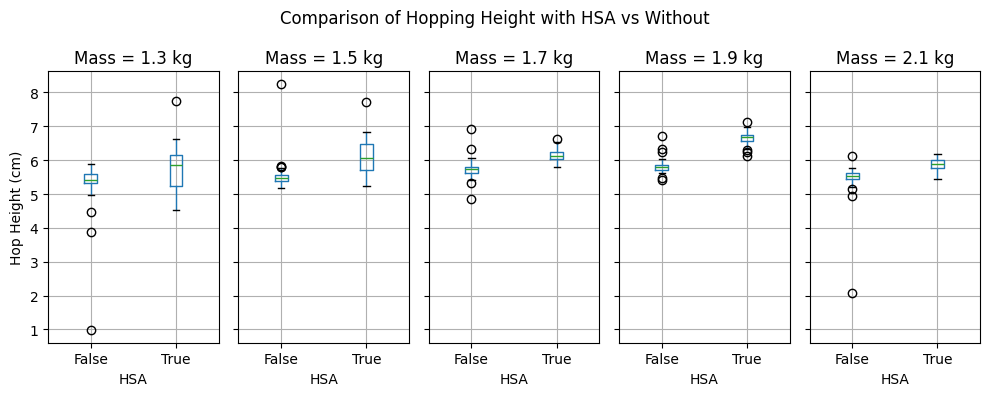

In [6]:
# sub_df = output_df[output_df['Mass'] == 1.3]
# sub_df.boxplot(column='Height', by='HSA')

masses = output_df['Mass'].unique()
fig, axs = plt.subplots(nrows=1,ncols=len(masses),sharey=True,figsize=(10,4))
for i, mass in enumerate(masses):
    sub_df = output_df[output_df['Mass'] == mass]
    sub_df.boxplot(column='Height', by='HSA', ax=axs[i])
    axs[i].set_title(f'Mass = {mass} kg')
axs[0].set_ylabel('Hop Height (cm)')
fig.suptitle('Comparison of Hopping Height with HSA vs Without')
fig.tight_layout()

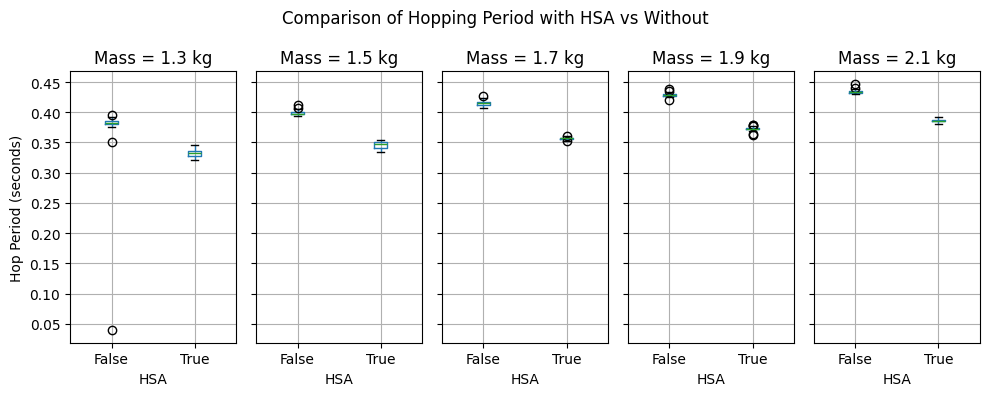

In [7]:

masses = output_df['Mass'].unique()
fig, axs = plt.subplots(nrows=1,ncols=len(masses),sharey=True,figsize=(10,4))
for i, mass in enumerate(masses):
    sub_df = output_df[output_df['Mass'] == mass]
    sub_df.boxplot(column='Period', by='HSA', ax=axs[i])
    axs[i].set_title(f'Mass = {mass} kg')
axs[0].set_ylabel('Hop Period (seconds)')
fig.suptitle('Comparison of Hopping Period with HSA vs Without')
fig.tight_layout()

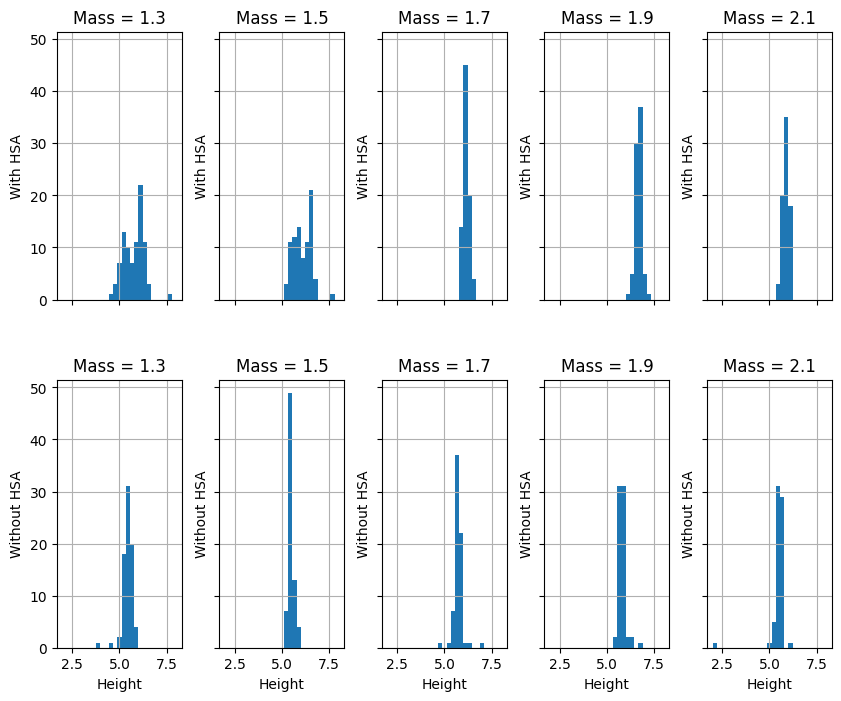

In [8]:
# look at distribution of hop heights
fig, axs = plt.subplots(nrows=2,ncols=len(masses), sharey=True, sharex=True, figsize=(10,8))
bins = np.linspace(2,8,28)
for i, mass in enumerate(masses):
    sub_df = output_df[output_df['Mass'] == mass]
    HSA_df = sub_df[sub_df['HSA']==True]
    HSA_df.hist(column='Height', ax=axs[0,i],bins=bins)
    NO_HSA_df = sub_df[sub_df['HSA']==False]
    NO_HSA_df.hist(column='Height', ax=axs[1,i],bins=bins)
    axs[0,i].set_title(f'Mass = {mass}')
    axs[1,i].set_title(f'Mass = {mass}')
    axs[0,i].set_ylabel('With HSA')
    axs[1,i].set_ylabel('Without HSA')
    axs[1,i].set_xlabel('Height')


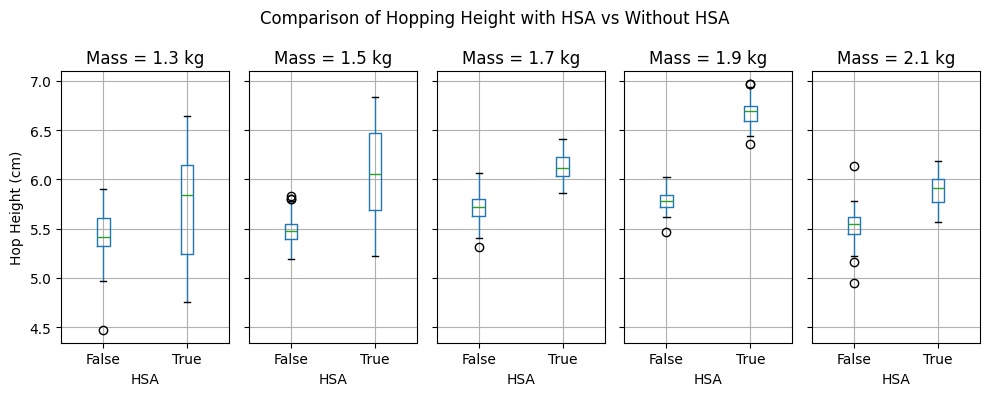

In [9]:
# looks like we can safely filter outliers by standard deviation / z-score
fig, axs = plt.subplots(nrows=1,ncols=len(masses),sharey=True,figsize=(10,4))
for i, mass in enumerate(masses):
    sub_df = output_df[output_df['Mass'] == mass]
    HSA_df = sub_df[sub_df['HSA'] == True]
    HSA_height_mean = HSA_df['Height'].mean()
    HSA_height_std = HSA_df['Height'].std()
    HSA_df_filt = HSA_df[abs(HSA_df['Height'] - HSA_height_mean) < 2*HSA_height_std]
    NO_HSA_df = sub_df[sub_df['HSA'] == False]
    NO_HSA_height_mean = NO_HSA_df['Height'].mean()
    NO_HSA_height_std = NO_HSA_df['Height'].std()
    NO_HSA_df_filt = NO_HSA_df[abs(NO_HSA_df['Height'] - NO_HSA_height_mean) < 2*NO_HSA_height_std]
    df = pd.concat((HSA_df_filt, NO_HSA_df_filt), ignore_index=True)
    df.boxplot(column='Height', by='HSA', ax=axs[i])
    axs[i].set_title(f'Mass = {mass} kg')
axs[0].set_ylabel('Hop Height (cm)')
fig.suptitle('Comparison of Hopping Height with HSA vs Without HSA')
fig.tight_layout()

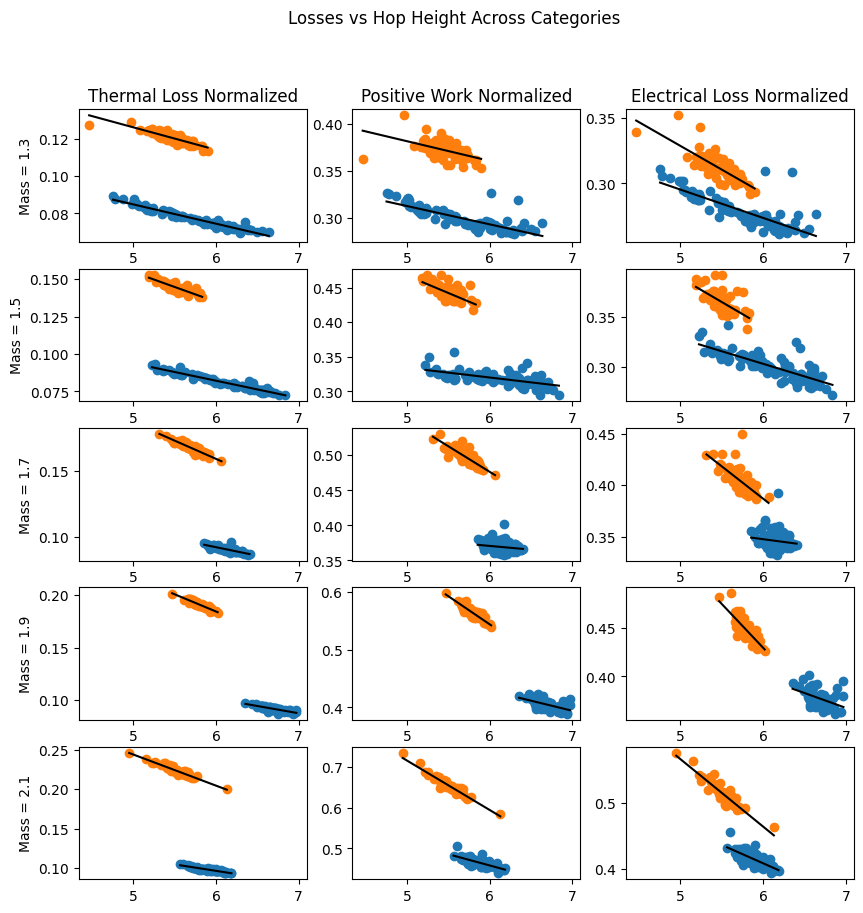

In [10]:
from scipy.stats.mstats import linregress
import scipy.stats
# Need to look at the difference in normalized losses and make sure they are not correlating too strongly
# with the hop height - otherwise I will need to retake some data
"""
Take losses without HSA, subtract losses with HSA, and plot against difference in hop heights.
Will have the outliers filtered for this state.
Hopefully the data is not super strongly correlated
"""

hsa_loss_predictions = {
}

no_hsa_loss_predictions = {
}

fig, axs = plt.subplots(nrows = len(masses), ncols = 3, figsize=(10,10), sharex=True)
for i, mass in enumerate(masses):
    sub_df = output_df[output_df['Mass'] == mass]
    HSA_df = sub_df[sub_df['HSA'] == True]
    HSA_height_mean = HSA_df['Height'].mean()
    HSA_height_std = HSA_df['Height'].std()
    HSA_df_filt = HSA_df[abs(HSA_df['Height'] - HSA_height_mean) < 2*HSA_height_std]
    NO_HSA_df = sub_df[sub_df['HSA'] == False]
    NO_HSA_height_mean = NO_HSA_df['Height'].mean()
    NO_HSA_height_std = NO_HSA_df['Height'].std()
    NO_HSA_df_filt = NO_HSA_df[abs(NO_HSA_df['Height'] - NO_HSA_height_mean) < 2*NO_HSA_height_std]

    keys = ['Thermal Loss Normalized', 'Positive Work Normalized', 'Electrical Loss Normalized']
    hsa_loss_predictions[mass] = {}
    no_hsa_loss_predictions[mass] = {}
    for j, key in enumerate(keys):
        y_hsa = HSA_df_filt[key].to_numpy()
        x_hsa = HSA_df_filt['Height'].to_numpy()
        hsa_fit = linregress(x_hsa,y_hsa)
        
        axs[i,j].scatter(x_hsa,y_hsa,color='C0')
        x_fit = np.array([min(x_hsa),max(x_hsa)])
        y_fit = hsa_fit.intercept + hsa_fit.slope*x_fit
        axs[i,j].plot(x_fit,y_fit,color='black')

        y_no_hsa = NO_HSA_df_filt[key].to_numpy()
        x_no_hsa = NO_HSA_df_filt['Height'].to_numpy()
        no_hsa_fit = linregress(x_no_hsa,y_no_hsa)
        x_fit = np.array([min(x_no_hsa),max(x_no_hsa)])
        y_fit = no_hsa_fit.intercept + no_hsa_fit.slope*x_fit
        axs[i,j].scatter(x_no_hsa,y_no_hsa,color='C1')
        axs[i,j].plot(x_fit,y_fit,color='black')
        axs[0,j].set_title(key)
        axs[i,0].set_ylabel(f'Mass = {mass}')
        axs[0,j].set_xlabel('Hop Height (cm)')
        axs[i,j].tick_params(labelbottom=True)

        mean_x = (np.sum(x_hsa)+np.sum(x_no_hsa))/(len(x_hsa)+len(x_no_hsa))
        y1 = hsa_fit.intercept + hsa_fit.slope*mean_x
        y2 = no_hsa_fit.intercept + no_hsa_fit.slope*mean_x


        # estimate the losses at x=6cm
        z = 6
        alpha = .05
        y = hsa_fit.intercept + hsa_fit.slope*z
        t_crit = scipy.stats.t.ppf(alpha/2,len(x_hsa)-2)
        x_mean = np.average(x_hsa)
        res = hsa_fit.intercept + hsa_fit.slope*x_hsa - y_hsa
        std = np.std(res)
        SEy_z = std*np.sqrt(1/len(x_hsa) + ((z-x_mean)**2) / np.sum((x_hsa-x_mean)**2))
        yerr = abs(t_crit)*SEy_z
        hsa_loss_predictions[mass][key] = (z,y,yerr)

        y = no_hsa_fit.intercept + no_hsa_fit.slope*z
        t_crit = scipy.stats.t.ppf(alpha/2,len(x_no_hsa)-2)
        x_mean = np.average(x_no_hsa)
        res = no_hsa_fit.intercept + no_hsa_fit.slope*x_no_hsa-y_no_hsa
        std = np.std(res)
        SEy_z = std*np.sqrt(1/len(x_no_hsa) + ((z-x_mean)**2) / np.sum((x_no_hsa-x_mean)**2))
        yerr = abs(t_crit)*SEy_z
        no_hsa_loss_predictions[mass][key] = (z,y,yerr)

    fig.suptitle('Losses vs Hop Height Across Categories')
plt.savefig('Losses_vs_height.png')

Predicted percent change in Thermal Loss Normalized: -34.58733549737856
Predicted percent change in Positive Work Normalized: -18.600034468900635
Predicted percent change in Electrical Loss Normalized: -6.384889513832621
Predicted percent change in Thermal Loss Normalized: -39.10593304677921
Predicted percent change in Positive Work Normalized: -23.251217032882757
Predicted percent change in Electrical Loss Normalized: -11.15822733203179
Predicted percent change in Thermal Loss Normalized: -41.94782982765661
Predicted percent change in Positive Work Normalized: -22.186511477531106
Predicted percent change in Electrical Loss Normalized: -10.187010001807023
Predicted percent change in Thermal Loss Normalized: -45.119335526757524
Predicted percent change in Positive Work Normalized: -21.161354050459284
Predicted percent change in Electrical Loss Normalized: -7.227640871766554
Predicted percent change in Thermal Loss Normalized: -52.7844780734688
Predicted percent change in Positive Work N

Text(0.5, 0.98, 'Comparison of Energy Losses of Hopping with/without an HSA')

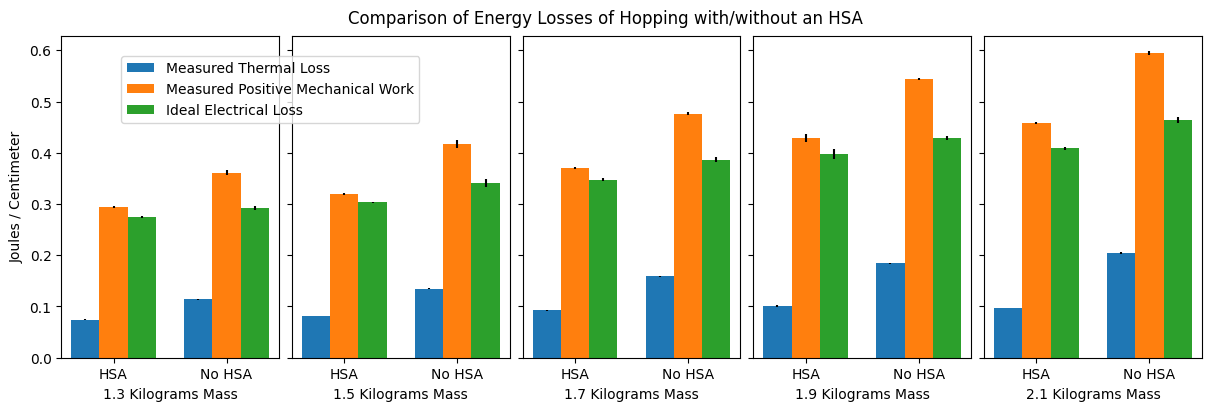

In [11]:

fig,ax = plt.subplots(nrows=1,ncols=5,layout='constrained',sharey=True, figsize=(12,4))
masses = [1.3,1.5,1.7,1.9,2.1]
for i,mass in enumerate(masses):
    # Left sub figure: boxplot comparing height-normalized thermal losses and positive work
    # for HSA vs no HSA at 1300g payload mass
    x = np.array([0,1])
    width = 0.25 # bar width
    multiplier = 0

    keys = ['Thermal Loss Normalized', 'Positive Work Normalized', 'Electrical Loss Normalized']
    for key in keys:
        offset = width * multiplier
        _,y_hsa,yerr_hsa = hsa_loss_predictions[mass][key]
        _,y_no_hsa,yerr_no_hsa = no_hsa_loss_predictions[mass][key]
        ax[i].bar(x+offset, [y_hsa, y_no_hsa], width, yerr=[yerr_hsa,yerr_no_hsa], label=key)
        multiplier += 1
        print(f'Predicted percent change in {key}: {(y_hsa-y_no_hsa)/y_no_hsa*100}')
    ax[i].set_xticks(x+width, ['HSA', 'No HSA'])
    ax[i].set_xlabel(f'{mass} Kilograms Mass')
    
ax[0].set_ylabel('Joules / Centimeter')
# ax[0].legend(['Measured Thermal Loss', 'Measured Positive Mechanical Work', 'Ideal Electrical Loss'],loc=(.3,.01))
fig.legend(['Measured Thermal Loss', 'Measured Positive Mechanical Work', 'Ideal Electrical Loss'],loc=(.1,.7))
fig.suptitle('Comparison of Energy Losses of Hopping with/without an HSA')

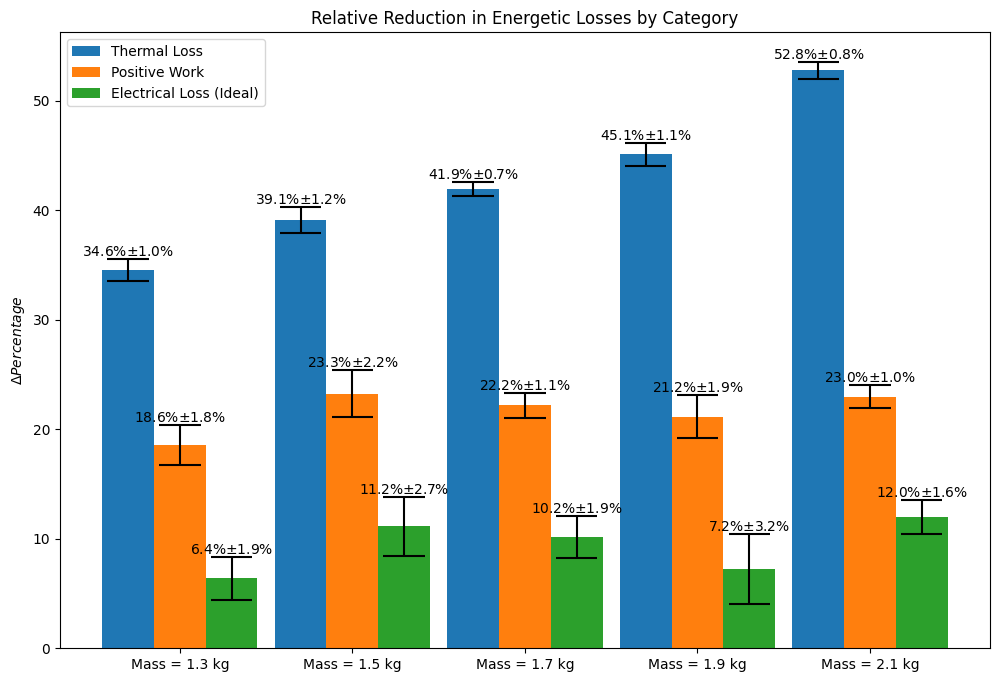

In [12]:
fig,ax = plt.subplots(figsize=(12,8)) # Left sub figure: boxplot comparing height-normalized thermal losses and positive work # for HSA vs no HSA at 1300g payload mass # x = np.array([0,1])
keys = ['Thermal Loss Normalized', 'Positive Work Normalized', 'Electrical Loss Normalized']
labels = dict(zip(keys, ['Thermal Loss', 'Positive Work', 'Electrical Loss (Ideal)']))
percents = {}
percent_err = {}
for i, key in enumerate(keys):
    percents[key] = np.zeros(len(masses))
    percent_err[key] = np.zeros((2,len(masses)))
    for j, mass in enumerate(masses):
        _,x,dx= hsa_loss_predictions[mass][key]
        _,y,dy= no_hsa_loss_predictions[mass][key]
        z = (y-x)/y
        z_lb = (y-x-dy-dx)/y
        z_ub = (y-x+dy+dx)/y

        percents[key][j] = z*100
        percent_err[key][0,j] = (z-z_lb)*100
        percent_err[key][1,j] = (z_ub-z)*100

x = np.arange(len(masses))
width = 0.3
offset = 0
multiplier = 0
for key, measurement in percents.items():
    offset = width * multiplier
    y = measurement
    yerr = percent_err[key]
    rects = ax.bar(x  + offset, measurement, width, yerr=percent_err[key], label=labels[key])
    bar_labels = [fr'${y[j]:.1f}\% ± {yerr[0,j]:.1f}\%$' for j in range(len(masses))]
    ax.bar_label(rects, labels=bar_labels, padding=0)
    ax.hlines(measurement+percent_err[key][0,:], (x+offset-.8*width/2), (x+offset+.8*width/2), color='black', )
    ax.hlines(measurement-percent_err[key][1,:], (x+offset-.8*width/2), (x+offset+.8*width/2), color='black', )
    multiplier += 1
ax.set_title('Relative Reduction in Energetic Losses by Category')
ax.set_ylabel(r'$Δ Percentage$')
ax.set_xticks(x + width, [f'Mass = {mass:.1f} kg' for mass in masses])
ax.legend()
plt.savefig('energy_losses_bar.png')

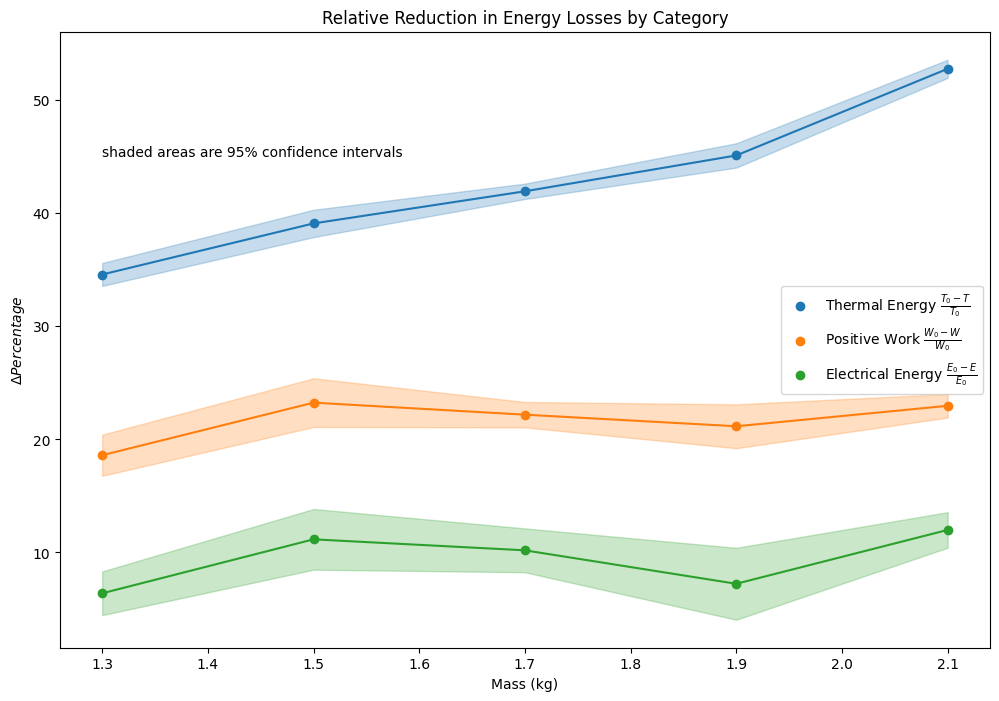

In [21]:
# same plot, but at shaded line plot
fig,ax = plt.subplots(figsize=(12,8)) # Left sub figure: boxplot comparing height-normalized thermal losses and positive work # for HSA vs no HSA at 1300g payload mass # x = np.array([0,1])
keys = ['Thermal Loss Normalized', 'Positive Work Normalized', 'Electrical Loss Normalized']
labels = dict(zip(keys, [r'Thermal Energy $\frac{T_0-T}{T_0}$', r'Positive Work $\frac{W_0-W}{W_0}$', r'Electrical Energy $\frac{E_0-E}{E_0}$']))
width = 0.3
offset = 0
multiplier = 0
for key, measurement in percents.items():
    key_idx = next(i for i, _key in enumerate(percent_err) if key == _key)
    color = f'C{key_idx}'
    ax.scatter(masses, measurement, color=color, label=labels[key])
    ax.plot(masses, measurement, color=color)
    y_min = measurement - percent_err[key][0]
    y_max = measurement + percent_err[key][1]
    ax.fill_between(masses, y_min, y_max, alpha=.25, color=color)
ax.set_title('Relative Reduction in Energy Losses by Category')
ax.set_ylabel(r'$Δ Percentage$')
ax.set_xlabel('Mass (kg)')
ax.text(1.3, 45, 'shaded areas are 95% confidence intervals')
ax.legend()
plt.savefig('energy_losses_line.png')

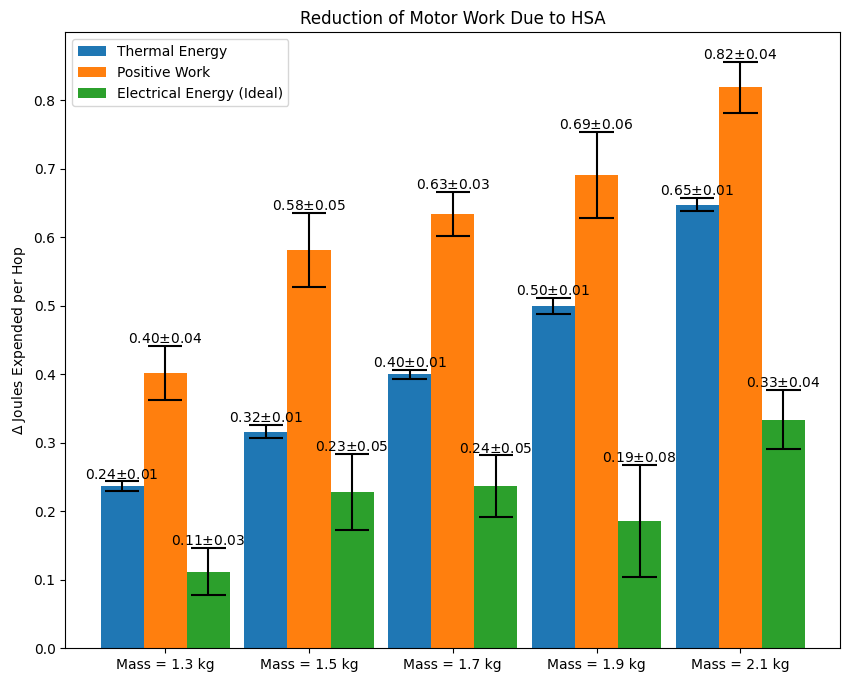

In [14]:

fig,ax = plt.subplots(figsize=(10,8)) # Left sub figure: boxplot comparing height-normalized thermal losses and positive work # for HSA vs no HSA at 1300g payload mass # x = np.array([0,1])
masses = np.array([1.3,1.5,1.7,1.9,2.1])
keys = ['Thermal Loss Normalized', 'Positive Work Normalized', 'Electrical Loss Normalized']
labels = dict(zip(keys, ['Thermal Energy', 'Positive Work', 'Electrical Energy (Ideal)']))
absolutes = {}
absolute_err= {}
for i, key in enumerate(keys):
    absolutes[key] = np.zeros(len(masses))
    absolute_err[key] = np.zeros((2,len(masses)))
    for j, mass in enumerate(masses):
        _,x,dx= hsa_loss_predictions[mass][key]
        _,y,dy= no_hsa_loss_predictions[mass][key]
        z = 6*(y-x)
        z_lb = 6*(y-x-dy-dx)
        z_ub = 6*(y-x+dy+dx)

        absolutes[key][j] = z
        absolute_err[key][0,j] = (z-z_lb)
        absolute_err[key][1,j] = (z_ub-z)

x = np.arange(len(masses))
width = 0.3
offset = 0
multiplier = 0
for key, measurement in absolutes.items():
    offset = width * multiplier
    y = measurement
    yerr = absolute_err[key]
    norm_factor = np.ones(len(masses))
    rects = ax.bar(x  + offset, measurement, width, yerr=absolute_err[key], label=labels[key])
    bar_labels = [fr'${y[j]:.2f} ± {yerr[0,j]:.2f}$' for j in range(len(masses))]
    ax.bar_label(rects, labels=bar_labels, padding=0)
    ax.hlines(measurement+absolute_err[key][0,:], (x+offset-.8*width/2), (x+offset+.8*width/2), color='black',)
    ax.hlines(measurement-absolute_err[key][1,:], (x+offset-.8*width/2), (x+offset+.8*width/2), color='black',)
    multiplier += 1
ax.set_title('Reduction of Motor Work Due to HSA')
ax.set_ylabel(r'$\Delta$ Joules Expended per Hop')
ax.set_xticks(x + width, [f'Mass = {mass:.1f} kg' for mass in masses])
ax.legend()
plt.savefig('energy_losses_absolute.png')

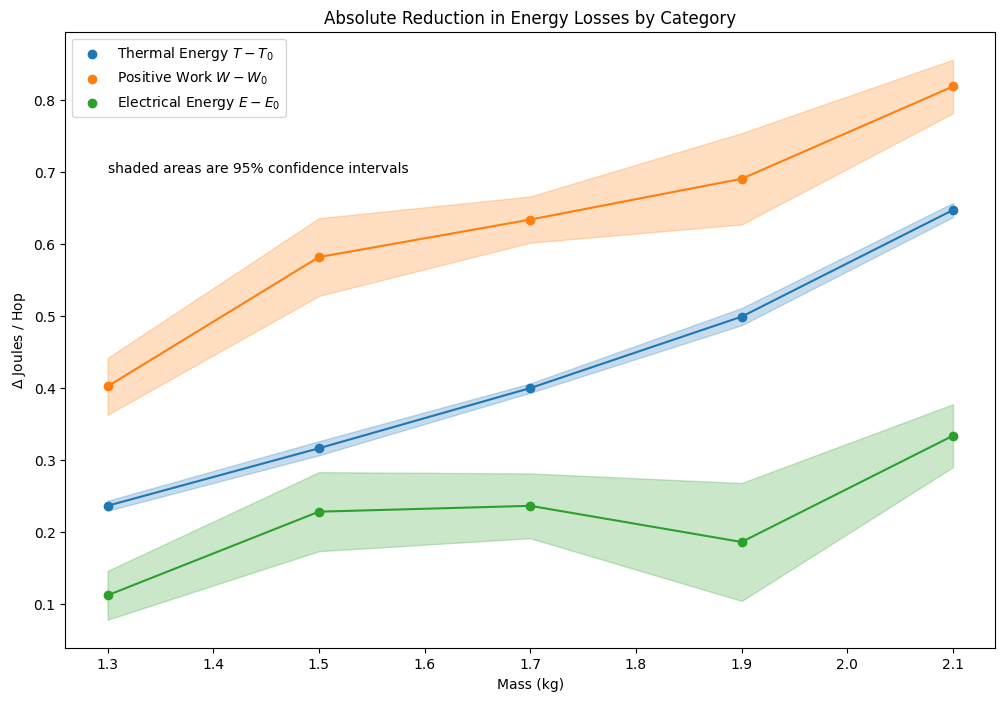

In [19]:

# same plot, but at shaded line plot
fig,ax = plt.subplots(figsize=(12,8)) # Left sub figure: boxplot comparing height-normalized thermal losses and positive work # for HSA vs no HSA at 1300g payload mass # x = np.array([0,1])
keys = ['Thermal Loss Normalized', 'Positive Work Normalized', 'Electrical Loss Normalized']
labels = dict(zip(keys, [r'Thermal Energy $T-T_0$', r'Positive Work $W-W_0$', r'Electrical Energy $E - E_0$']))
width = 0.3
offset = 0
multiplier = 0
for key, measurement in absolutes.items():
    key_idx = next(i for i, _key in enumerate(percent_err) if key == _key)
    color = f'C{key_idx}'
    ax.scatter(masses, measurement, color=color, label=labels[key])
    ax.plot(masses, measurement, color=color)
    y_min = measurement - absolute_err[key][0]
    y_max = measurement + absolute_err[key][1]
    ax.fill_between(masses, y_min, y_max, alpha=.25, color=color)
ax.set_title('Absolute Reduction in Energy Losses by Category')
ax.set_ylabel(r'$Δ$ Joules / Hop')
ax.set_xlabel('Mass (kg)')
ax.text(1.3, 0.7, 'shaded areas are 95% confidence intervals')
ax.legend()
plt.savefig('energy_losses_absolute_line.png')

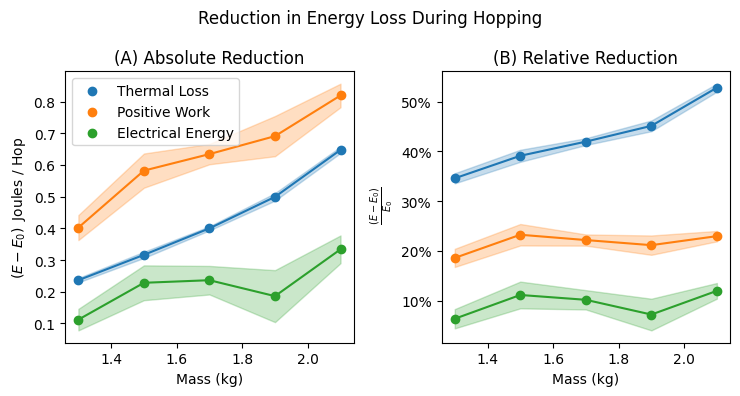

In [53]:
# absolute and percentage diffs in two-column figure
fig, ax = plt.subplots(nrows=1,ncols=2, figsize=(7.5,4))
keys = ['Thermal Loss Normalized', 'Positive Work Normalized', 'Electrical Loss Normalized']
labels = dict(zip(keys, [r'Thermal Loss', r'Positive Work', r'Electrical Energy']))
width = 0.3
offset = 0
multiplier = 0
for key, measurement in absolutes.items():
    key_idx = next(i for i, _key in enumerate(percent_err) if key == _key)
    color = f'C{key_idx}'
    ax[0].scatter(masses, measurement, color=color, label=labels[key])
    ax[0].plot(masses, measurement, color=color)
    y_min = measurement - absolute_err[key][0]
    y_max = measurement + absolute_err[key][1]
    ax[0].fill_between(masses, y_min, y_max, alpha=.25, color=color)
# ax[0].set_title('Absolute Reduction in Energy Losses by Category')
ax[0].set_ylabel(r'$(E-E_0) \,$ Joules / Hop')
ax[0].set_xlabel('Mass (kg)')
ax[0].set_title('(A) Absolute Reduction')
ax[0].legend()


# labels = dict(zip(keys, [r'$\frac{T_0-T}{T_0}$', r'$\frac{W_0-W}{W_0}$', r'$\frac{E_0-E}{E_0}$']))
width = 0.3
offset = 0
multiplier = 0
for key, measurement in percents.items():
    key_idx = next(i for i, _key in enumerate(percent_err) if key == _key)
    color = f'C{key_idx}'
    ax[1].scatter(masses, measurement, color=color, label=labels[key])
    ax[1].plot(masses, measurement, color=color)
    y_min = measurement - percent_err[key][0]
    y_max = measurement + percent_err[key][1]
    ax[1].fill_between(masses, y_min, y_max, alpha=.25, color=color)
# ax[1].set_title('Relative Reduction in Energy Losses by Category')
ax[1].set_ylabel(r' $\frac{(E-E_0)}{E_0}$')
ax[1].set_xlabel('Mass (kg)')
ax[1].set_title('(B) Relative Reduction')

import matplotlib.ticker as mtick
ax[1].yaxis.set_major_formatter(mtick.PercentFormatter())
fig.suptitle('Reduction in Energy Loss During Hopping')
fig.tight_layout()

plt.savefig('hopping_result.png',dpi=900)